In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# Init data

shapeMatrix = pd.read_pickle("../data/resmat.pkl")
shapeMatrix.fillna(0, inplace=True)
normalized_shapeMatrix=(shapeMatrix-shapeMatrix.mean())/shapeMatrix.std()
pca = PCA(shapeMatrix.shape[0]-1)
pca.fit(normalized_shapeMatrix)

,n_components,182
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [5]:
np.save("../data/resmat.npy", shapeMatrix.values)

In [ ]:
# Instead of summing and averaging, store all the results
all_random_eigenvalues = []
for i in tqdm(range(100), desc="Simulations"):
    random_shapeMatrix = pd.DataFrame(np.random.normal(0, 1, shapeMatrix.shape))
    pca_random = PCA(shapeMatrix.shape[0]-1)
    pca_random.fit(random_shapeMatrix)
    all_random_eigenvalues.append(pca_random.explained_variance_ratio_)

# Calculate the 95th percentile across the 100 simulations for each component
percentile_eigenvalues = np.percentile(all_random_eigenvalues, 95, axis=0)

In [34]:
# You should have these variables from your previous code:
# pca.explained_variance_ratio_  <-- Eigenvalues from your REAL data
# percentile_eigenvalues         <-- The 95th percentile eigenvalues from RANDOM data

# Compare the two arrays element-wise and sum the 'True' results
n_factors_to_retain = sum(pca.explained_variance_ratio_ > percentile_eigenvalues)

print(f"Based on the 95th percentile rule, you should retain: {n_factors_to_retain} factors.")

Based on the 95th percentile rule, you should retain: 19 factors.


In [36]:
np.save("../result/percentile_eigenvalues.npy", percentile_eigenvalues)

Running PCA on actual data...
Running 1000 simulations in parallel on all available cores...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [21:33<00:00,  1.29s/it]



Based on the 95th percentile rule, you should retain: 19 factors.
Saved percentile eigenvalues to: ../result/parallel-analysis/percentile_eigenvalues_1000.npy


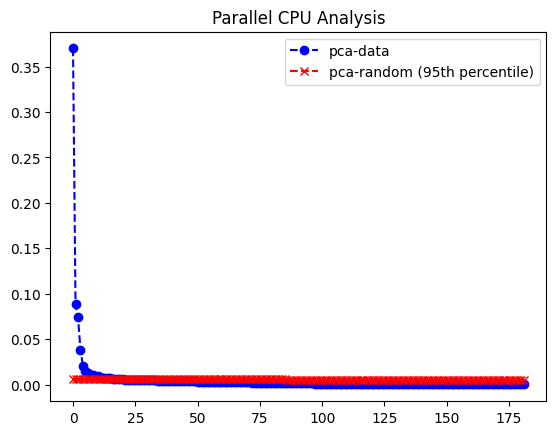

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed # <-- Import joblib

# --- 1. Define the function for a SINGLE simulation ---
# This function contains the logic from one iteration of your original loop.
# It takes the shape of the matrix as an argument.
def run_single_pca_simulation(matrix_shape):
    """
    Generates a random matrix, runs PCA, and returns the explained variance ratio.
    """
    # Create random data (no need for a DataFrame here, NumPy is faster)
    random_matrix = np.random.normal(0, 1, matrix_shape)
    
    # We can use the faster 'randomized' solver here as well
    n_components = matrix_shape[0] - 1
    pca_random = PCA(n_components=n_components, svd_solver='randomized')
    pca_random.fit(random_matrix)
    
    return pca_random.explained_variance_ratio_

# --- Main Script ---
shapeMatrix = pd.read_pickle("../data/resmat.pkl")
shapeMatrix.fillna(0, inplace=True)
normalized_shapeMatrix = (shapeMatrix - shapeMatrix.mean()) / shapeMatrix.std()

# --- Run PCA on your actual data (this part is the same) ---
print("Running PCA on actual data...")
pca = PCA(shapeMatrix.shape[0] - 1)
pca.fit(normalized_shapeMatrix)
real_eigenvalues = pca.explained_variance_ratio_

# --- 2. Run the 100 simulations IN PARALLEL ---
n_simulations = 1000
print(f"Running {n_simulations} simulations in parallel on all available cores...")

# n_jobs=-1 tells joblib to use ALL available CPU cores (16 in your case)
# The tqdm(range(...)) gives you a progress bar.
results = Parallel(n_jobs=-1)(
    delayed(run_single_pca_simulation)(shapeMatrix.shape) for i in tqdm(range(n_simulations))
)

# --- 3. Aggregate the results and plot (this part is the same) ---
all_random_eigenvalues = np.array(results)
percentile_eigenvalues = np.percentile(all_random_eigenvalues, 95, axis=0)

n_factors_to_retain = sum(real_eigenvalues > percentile_eigenvalues)
print(f"\nBased on the 95th percentile rule, you should retain: {n_factors_to_retain} factors.")
output_dir = "../result/parallel-analysis"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
np.save(f"{output_dir}/percentile_eigenvalues_{n_simulations}.npy", percentile_eigenvalues)
print(f"Saved percentile eigenvalues to: {output_dir}/percentile_eigenvalues_{n_simulations}.npy")

plt.plot(real_eigenvalues, '--bo', label='pca-data')
plt.plot(percentile_eigenvalues, '--rx', label='pca-random (95th percentile)')
plt.legend()
plt.title('Parallel CPU Analysis')
plt.show()

Loading and preparing data...
Normalizing data (this may take a moment)...
Data normalized successfully.
Running PCA on actual data...
Running 100 simulations in parallel...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:52<00:00,  1.13s/it]



--- Analysis Complete ---
✅ Parallel Analysis (95th percentile rule) recommends: 19 factors.
✅ Kaiser Criterion (eigenvalue > 1 rule) recommends: 182 factors.


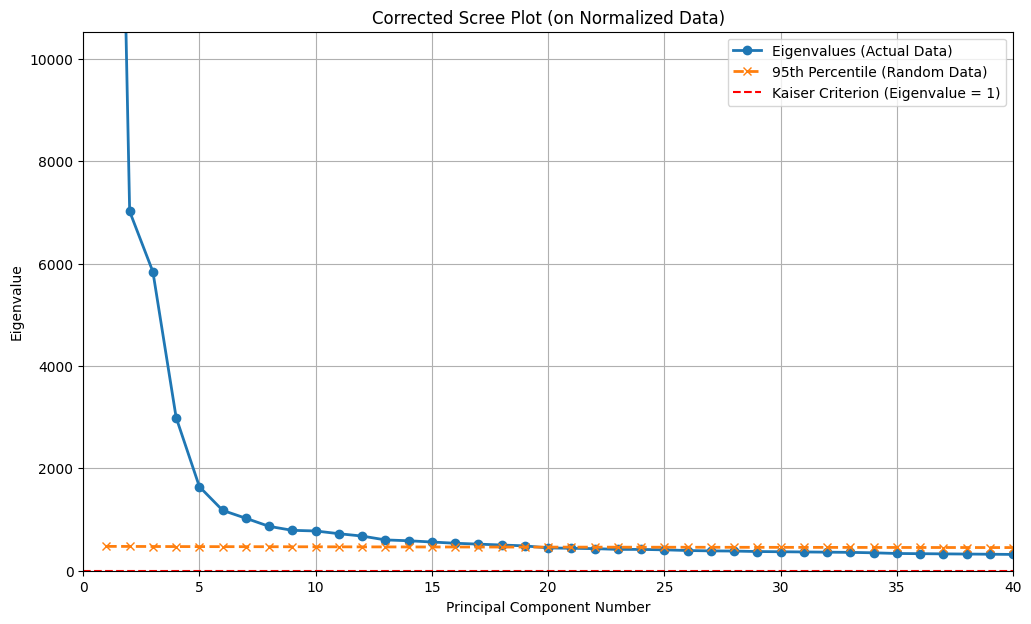

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import os

# --- 1. Define the function for a SINGLE simulation ---
def run_single_pca_simulation(matrix_shape):
    """
    Generates a random NORMALIZED matrix, runs PCA, and returns the eigenvalues.
    """
    # Create random data
    random_matrix = np.random.normal(0, 1, matrix_shape)
    # The random data is already 'standardized' by definition (mean=0, std=1)
    
    n_components = matrix_shape[0] - 1
    # Note: No need for 'randomized' solver on this size of random data, 
    # the standard 'auto' is efficient.
    pca_random = PCA(n_components=n_components)
    pca_random.fit(random_matrix)
    
    # Return the raw eigenvalues (explained_variance_)
    return pca_random.explained_variance_

# ===================================================================
# --- Main Script ---
# ===================================================================

# --- 2. Load and Prepare Data ---
print("Loading and preparing data...")
shapeMatrix = pd.read_pickle("../data/resmat.pkl")
shapeMatrix.fillna(0, inplace=True)

# --- 3. NORMALIZE THE DATA ---
# This is the critical step. We standardize the data to have a mean of 0 and a variance of 1.
# This is equivalent to running PCA on the correlation matrix.
print("Normalizing data (this may take a moment)...")
scaler = StandardScaler()
normalized_shapeMatrix = scaler.fit_transform(shapeMatrix)
print("Data normalized successfully.")

# --- 4. Run PCA on your ACTUAL NORMALIZED data ---
print("Running PCA on actual data...")
n_components = normalized_shapeMatrix.shape[0] - 1
pca = PCA(n_components=n_components)
pca.fit(normalized_shapeMatrix)
# Get the raw eigenvalues for the real data
real_eigenvalues = pca.explained_variance_

# --- 5. Run simulations IN PARALLEL on all CPU cores ---
n_simulations = 100
print(f"Running {n_simulations} simulations in parallel...")
results = Parallel(n_jobs=-1)(
    delayed(run_single_pca_simulation)(normalized_shapeMatrix.shape) for i in tqdm(range(n_simulations))
)

# --- 6. Aggregate results and find the number of factors ---
all_random_eigenvalues = np.array(results)
percentile_eigenvalues = np.percentile(all_random_eigenvalues, 95, axis=0)

# Find the number of factors from Parallel Analysis
n_factors_parallel = sum(real_eigenvalues > percentile_eigenvalues)

# Find the number of factors from the (now valid) Kaiser Criterion
n_factors_kaiser = sum(real_eigenvalues > 1)

print("\n--- Analysis Complete ---")
print(f"✅ Parallel Analysis (95th percentile rule) recommends: {n_factors_parallel} factors.")
print(f"✅ Kaiser Criterion (eigenvalue > 1 rule) recommends: {n_factors_kaiser} factors.")


# --- 7. Generate the Final Scree Plot ---
plt.figure(figsize=(12, 7))
x_values = range(1, n_components + 1)

plt.plot(x_values, real_eigenvalues, 'o-', linewidth=2, label='Eigenvalues (Actual Data)')
plt.plot(x_values, percentile_eigenvalues, 'x--', linewidth=2, label='95th Percentile (Random Data)')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (Eigenvalue = 1)')

plt.title('Corrected Scree Plot (on Normalized Data)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue')
plt.grid()
plt.legend()
# Focus on the most important part of the plot
plt.xlim(0, 40) 
plt.ylim(0, max(real_eigenvalues[1:])*1.5) # Zoom in, ignoring the first factor for scale

# Save the plot
output_dir = "../results"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, "corrected_scree_plot.png"))
plt.show()

In [ ]:
# Create a sample binary response matrix (resmat)
# Let's assume 200 students and 20 items
set.seed(123) # for reproducibility
true_abilities <- matrix(rnorm(200 * 2), 200, 2) # 2 underlying skills
item_diffs <- matrix(rnorm(20 * 2, 0, 0.5), 20, 2)
log_odds <- true_abilities %*% t(item_diffs)
prob_correct <- 1 / (1 + exp(-log_odds))
resmat <- matrix(rbinom(200 * 20, 1, prob_correct), 200, 20)